# **Preprocessing**

In [1]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
# Loading the data
input_path = Path("..") / 'data' / 'processed' / 'dataset_processed.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
0,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
1,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
3,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
4,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164


Shape of the piezometer dataframe:
 (3487, 36)


In [15]:
df.columns.tolist()

['latitude',
 'longitude',
 'temperature_2m_max',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'date_index',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur',
 'P_cum_30d',
 'P_cum_90d',
 'Peff_cum_30d',
 'Peff_cum_90d',
 'Temperature_mean_30d',
 'Temperature_mean_90d',
 'SPLI',
 'SPI',
 'SETI',
 'SSTI',
 'SSRI',
 'SWSI',
 'SCCI',
 'SPMI',
 'SPEI',
 'SSMI']

In [7]:
df = df.set_index("date_index", drop=False)
df.index = pd.to_datetime(df.index)
display(df.head(5))

,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,,,,,,,,,,,,
2017-01-01,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-02,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-03,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-04,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-05,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164


In [8]:
print(df['niveau_nappe_eau'].tail(20))

date_index
2026-06-30    104.13
2026-07-01    104.11
2026-07-02    104.09
2026-07-03    104.08
2026-07-04    104.05
2026-07-05    104.03
2026-07-06    104.05
2026-07-07    104.08
2026-07-08    104.09
2026-07-09    104.05
2026-07-10    103.99
2026-07-11    103.97
2026-07-12    103.92
2026-07-13    103.86
2026-07-14    103.84
2026-07-15    103.85
2026-07-16    103.84
2026-07-17    103.86
2026-07-18    103.87
2026-07-19    103.84
Name: niveau_nappe_eau, dtype: float64


In [9]:
from src.features.features_engineering import standardize_index
result = standardize_index(df['niveau_nappe_eau'], scale=1, agg='mean')
print(result.tail(10))

date_index
2025-10-01   -1.543098
2025-11-01   -1.543098
2025-12-01   -1.543098
2026-01-01    1.018795
2026-02-01    1.595180
2026-03-01    1.595180
2026-04-01    1.595180
2026-05-01    1.595180
2026-06-01    0.665190
2026-07-01    0.380523
Freq: MS, Name: niveau_nappe_eau_s1, dtype: float64


In [10]:
m = df['niveau_nappe_eau'].resample('MS').mean()
print(m.tail(10))

date_index
2025-10-01    102.090323
2025-11-01    101.230667
2025-12-01    101.298387
2026-01-01    103.330645
2026-02-01    104.177857
2026-03-01    104.414194
2026-04-01    104.358333
2026-05-01    104.325161
2026-06-01    104.205333
2026-07-01    103.972105
Freq: MS, Name: niveau_nappe_eau, dtype: float64


In [11]:
m = df['niveau_nappe_eau'].resample('MS').mean()
print(m.groupby(m.index.month).count())

date_index
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8      9
9      9
10     9
11     9
12     9
Name: niveau_nappe_eau, dtype: int64


In [13]:
print(m[m.index.month == 2])
print(m[m.index.month == 3])
print(m[m.index.month == 4])
print(m[m.index.month == 5])

date_index
2017-02-01    102.310000
2018-02-01    101.863929
2019-02-01    103.100714
2020-02-01    103.784138
2021-02-01    101.715000
2022-02-01    102.967857
2023-02-01    101.033036
2024-02-01    100.972069
2025-02-01    101.018571
2026-02-01    104.177857
Name: niveau_nappe_eau, dtype: float64
date_index
2017-03-01    103.202258
2018-03-01    101.670645
2019-03-01    102.795161
2020-03-01    103.917419
2021-03-01    102.002258
2022-03-01    102.974194
2023-03-01    100.792581
2024-03-01    100.438065
2025-03-01    101.521355
2026-03-01    104.414194
Name: niveau_nappe_eau, dtype: float64
date_index
2017-04-01    103.996667
2018-04-01    102.037333
2019-04-01    102.757667
2020-04-01    104.066333
2021-04-01    102.037000
2022-04-01    102.782667
2023-04-01    100.717000
2024-04-01    100.179333
2025-04-01    102.072933
2026-04-01    104.358333
Name: niveau_nappe_eau, dtype: float64
date_index
2017-05-01    104.110968
2018-05-01    103.157742
2019-05-01    103.141613
2020-05-01    

In [14]:
# Setting 'date_index' as index in the dataframe
df = df.set_index("date_index", drop=False)
df.index = pd.to_datetime(df.index)
    
# Build the monthly panel
std_cols = df.filter(regex=r"^S.*I$").columns
df = df.filter(std_cols)
df_monthly = df.groupby(df.index.to_period('M')).mean()

In [15]:
df_monthly.tail(10)

,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,
2025-10,-1.543098,-0.950014,0.000000,-0.278405,0.278405,-0.580758,0.580758,0.278405,-0.580758,0.000000
2025-11,-1.543098,0.000000,0.580758,0.580758,0.580758,0.580758,-0.278405,-0.278405,-0.278405,-0.580758
2025-12,-1.543098,1.543098,-0.950014,0.580758,-1.543098,-0.950014,0.950014,-0.580758,1.543098,0.000000
2026-01,1.018795,1.018795,-1.595180,-0.380523,-1.595180,-0.380523,1.595180,-1.595180,1.018795,1.018795
2026-02,1.595180,1.595180,-0.380523,-0.124164,-1.595180,0.380523,1.018795,-1.595180,1.595180,1.595180
2026-03,1.595180,1.595180,-0.124164,-0.380523,-0.124164,1.595180,-0.380523,0.380523,1.018795,1.018795
2026-04,1.595180,-0.380523,1.018795,0.665190,1.018795,0.380523,-1.018795,1.018795,-0.665190,0.124164
2026-05,1.595180,-0.665190,1.018795,1.018795,1.595180,-0.380523,-1.018795,1.018795,-0.665190,0.380523
2026-06,0.665190,-0.380523,1.595180,0.665190,1.595180,1.018795,-1.595180,1.595180,-1.595180,-0.124164


In [16]:
df_test = df_monthly.iloc[-7:-4]
print(df_test.index)

PeriodIndex(['2026-01', '2026-02', '2026-03'], dtype='period[M]', name='date_index')


In [ ]:
#display(df_monthly)

,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,
2017-01,0.124164,0.665190,0.380523,-1.018795,-0.124164,0.665190,-1.018795,0.665190,0.665190,0.124164
2017-02,0.124164,0.665190,-0.124164,-0.380523,-0.124164,0.124164,-0.124164,-0.380523,0.665190,1.018795
2017-03,0.665190,0.665190,1.018795,0.665190,1.018795,-1.018795,-1.018795,0.124164,0.380523,1.595180
2017-04,0.665190,-1.595180,1.595180,0.124164,1.595180,1.018795,-1.595180,1.595180,-1.595180,1.018795
2017-05,0.665190,-0.380523,-0.124164,-0.124164,0.380523,-1.595180,-0.380523,0.124164,-0.380523,0.665190
...,...,...,...,...,...,...,...,...,...,...
2026-03,1.595180,1.595180,-0.124164,-0.380523,-0.124164,1.595180,-0.380523,0.380523,1.018795,1.018795
2026-04,1.595180,-0.380523,1.018795,0.665190,1.018795,0.380523,-1.018795,1.018795,-0.665190,0.124164
2026-05,1.595180,-0.665190,1.018795,1.018795,1.595180,-0.380523,-1.018795,1.018795,-0.665190,0.380523


In [ ]:
#df_train = df_monthly.iloc[:-4]
#df_test = df_monthly.iloc[-4:-1,:]

In [ ]:
#print(df_train)

                SPLI       SPI      SETI      SSTI      SSRI      SWSI  \
date_index                                                               
2017-01     0.124164  0.665190  0.380523 -1.018795 -0.124164  0.665190   
2017-02     0.124164  0.665190 -0.124164 -0.380523 -0.124164  0.124164   
2017-03     0.665190  0.665190  1.018795  0.665190  1.018795 -1.018795   
2017-04     0.665190 -1.595180  1.595180  0.124164  1.595180  1.018795   
2017-05     0.665190 -0.380523 -0.124164 -0.124164  0.380523 -1.595180   
...              ...       ...       ...       ...       ...       ...   
2025-11    -1.543098  0.000000  0.580758  0.580758  0.580758  0.580758   
2025-12    -1.543098  1.543098 -0.950014  0.580758 -1.543098 -0.950014   
2026-01     1.018795  1.018795 -1.595180 -0.380523 -1.595180 -0.380523   
2026-02     1.595180  1.595180 -0.380523 -0.124164 -1.595180  0.380523   
2026-03     1.595180  1.595180 -0.124164 -0.380523 -0.124164  1.595180   

                SCCI      SPMI      S

In [ ]:
#print(df_test)

               SPLI       SPI      SETI      SSTI      SSRI      SWSI  \
date_index                                                              
2026-04     1.59518 -0.380523  1.018795  0.665190  1.018795  0.380523   
2026-05     1.59518 -0.665190  1.018795  1.018795  1.595180 -0.380523   
2026-06     0.66519 -0.380523  1.595180  0.665190  1.595180  1.018795   

                SCCI      SPMI     SPEI      SSMI  
date_index                                         
2026-04    -1.018795  1.018795 -0.66519  0.124164  
2026-05    -1.018795  1.018795 -0.66519  0.380523  
2026-06    -1.595180  1.595180 -1.59518 -0.124164  


In [ ]:
def preprocessing(df):
    """
    This function performed the following steps:
    1. preprocessing preparation (dropping undesire columns; splitting the target 'y' and the explicatives features 'X')
    2. Temporal split (X_train; X_test; y_train & y_test)
    At the end, this function return the different datasets to perform Machine Learning algorithms.
    """
    # Setting 'date_index' as index in the dataframe
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    
    # Build the monthly panel
    std_cols = df.filter(regex=r"^S.*I$").columns
    df = df.filter(std_cols)
    df_monthly = df.groupby(df.index.to_period('M')).mean()
    
    # Definition of the target
    df_monthly['SPLI_1m'] = df_monthly['SPLI'].shift(-1) # SPLI from the next month
    df_monthly['SPLI_2m'] = df_monthly['SPLI'].shift(-2) # SPLI from the next two months
    df_monthly['SPLI_3m'] = df_monthly['SPLI'].shift(-3) # SPLI from the next three months
    
    # Temporal split (80/20% for the train/test sets split)
    df_train = df_monthly.iloc[:-7]
    df_test = df_monthly.iloc[-7:-4]
    
    # Split X/y     
    y_train_1m = df_train['SPLI_1m']
    y_train_2m = df_train['SPLI_2m']
    y_train_3m = df_train['SPLI_3m']
    X_train = df_train.drop(columns=['SPLI', 'SPLI_1m', 'SPLI_2m', 'SPLI_3m'])
   
    y_test_1m = df_test['SPLI_1m']
    y_test_2m = df_test['SPLI_2m']
    y_test_3m = df_test['SPLI_3m']
    X_test = df_test.drop(columns=['SPLI', 'SPLI_1m', 'SPLI_2m', 'SPLI_3m'])
    
    return X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m

In [ ]:
X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

In [18]:
spli_test_preprocess = pd.DataFrame({
    'y_test_1m': y_test_1m,
    'y_test_2m': y_test_2m,
    'y_test_3m': y_test_3m
})
display(spli_test_preprocess)

,y_test_1m,y_test_2m,y_test_3m
date_index,,,
2026-01,1.59518,1.59518,1.59518
2026-02,1.59518,1.59518,1.59518
2026-03,1.59518,1.59518,0.66519


In [22]:
print(df_monthly['SPLI'].tail(10))

date_index
2025-10   -1.543098
2025-11   -1.543098
2025-12   -1.543098
2026-01    1.018795
2026-02    1.595180
2026-03    1.595180
2026-04    1.595180
2026-05    1.595180
2026-06    0.665190
2026-07    0.380523
Freq: M, Name: SPLI, dtype: float64


# **Machine Learning**

## Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
def linear_regression(df):
    """
    Function to run a Linear Regression on a train and test set.
    Return the prediction and evaluation metrics (R2 on train and test, RMSE, MAE)
    """
    X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

    y_trains = [y_train_1m, y_train_2m, y_train_3m]
    y_tests  = [y_test_1m,  y_test_2m,  y_test_3m]

    preds   = {}
    metrics = {'R2_train': [], 'R2_test': [], 'RMSE': [], 'MAE': []}

    for i, (y_train, y_test) in enumerate(zip(y_trains, y_tests), start=1):
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[f'y_test_{i}m'] = y_test.values
        preds[f'y_pred_{i}m'] = y_pred

        metrics['R2_train'].append(model.score(X_train, y_train))
        metrics['R2_test'].append(model.score(X_test, y_test))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
        metrics['MAE'].append(mean_absolute_error(y_test, y_pred))

    predictions = pd.DataFrame(preds, index=y_test_1m.index)
    evaluation_metrics_lr = pd.DataFrame(metrics, index=['Prediction_1m', 'Prediction_2m', 'Prediction_3m'])

    return predictions, evaluation_metrics_lr

In [ ]:
predictions_lr, evaluation_metrics_lr = linear_regression(df)

date_index
2026-01    1.59518
2026-02    1.59518
2026-03    0.66519
Freq: M, Name: SPLI_3m, dtype: float64


In [ ]:
evaluation_metrics_lr

,R2_train,R2_test,RMSE,MAE
Prediction_1m,0.55542,0.000000,1.058452,1.014292
Prediction_2m,0.52913,0.000000,0.930605,0.896547
Prediction_3m,0.47496,-2.006095,0.760105,0.601472


In [ ]:
predictions_lr

,y_test_1m,y_pred_1m,y_test_2m,y_pred_2m,y_test_3m,y_pred_3m
date_index,,,,,,
2026-01,1.59518,0.230775,1.59518,0.396433,1.59518,0.406045
2026-02,1.59518,0.968931,1.59518,1.007368,1.59518,1.032640
2026-03,1.59518,0.542958,1.59518,0.692098,0.66519,0.717931


## STL forecast

In [28]:
from statsmodels.tsa.seasonal import STL

In [29]:
def stl_forecast(df, period=12):
    X_train, y_train_1m, y_train_2m, y_train_3m, \
    X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

    stl = STL(df_monthly['SPLI'], period=period, robust=True)
    result = stl.fit()

    trend    = result.trend
    seasonal = result.seasonal
    n_test   = len(y_test_1m)

    # ✅ Bug 1 corrigé : scalaire pour np.full
    trend_last     = trend.iloc[-(n_test + 1)]
    trend_forecast = np.full(n_test, trend_last)

    # ✅ Bug 3 corrigé : alignement explicite par index de période
    test_months = y_test_1m.index  # PeriodIndex
    seasonal_forecast = np.array([
        seasonal[seasonal.index.month == m.month].iloc[-1]
        for m in test_months
    ])

    y_tests = [y_test_1m, y_test_2m, y_test_3m]
    preds   = {}
    metrics = {'R2_train': [], 'R2_test': [], 'RMSE': [], 'MAE': []}

    # ✅ Bug 4 corrigé : R2_train calculé une seule fois
    r2_train = r2_score(
        df_monthly['SPLI'].iloc[:-n_test],
        (trend + seasonal).iloc[:-n_test]
    )

    y_pred = trend_forecast + seasonal_forecast  # identique pour les 3 horizons

    for i, y_test in enumerate(y_tests, start=1):
        preds[f'y_test_{i}m'] = y_test.values
        preds[f'y_pred_{i}m'] = y_pred  # ⚠️ voir note ci-dessous

        metrics['R2_train'].append(r2_train)
        metrics['R2_test'].append(r2_score(y_test, y_pred))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
        metrics['MAE'].append(mean_absolute_error(y_test, y_pred))

    predictions_stl   = pd.DataFrame(preds, index=y_test_1m.index.to_timestamp())
    evaluation_stl    = pd.DataFrame(
        metrics, index=['Prediction_1m', 'Prediction_2m', 'Prediction_3m']
    )
    return predictions_stl, evaluation_stl

In [30]:
predictions_stl, evaluation_stl = stl_forecast(df, period=12)

In [31]:
predictions_stl

,y_test_1m,y_pred_1m,y_test_2m,y_pred_2m,y_test_3m,y_pred_3m
date_index,,,,,,
2025-10-01,-1.543098,-0.307126,-1.543098,-0.307126,1.018795,-0.307126
2025-11-01,-1.543098,-0.065676,1.018795,-0.065676,1.595180,-0.065676
2025-12-01,1.018795,-0.427254,1.595180,-0.427254,1.595180,-0.427254


In [32]:
evaluation_stl

,R2_train,R2_test,RMSE,MAE
Prediction_1m,0.752515,-0.325887,1.390618,1.386481
Prediction_2m,0.752515,-0.217240,1.504875,1.447626
Prediction_3m,0.752515,-37.860146,1.693788,1.669737


In [6]:
def stl_forecast(df, period=12):
    """
    STL decomposition baseline on full df_monthly series.
    Forecast SPLI using trend + seasonal components.
    Return predictions and evaluation metrics (R2, RMSE, MAE).
    """
    X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

    # STL sur la série complète SPLI de df_monthly
    stl = STL(df_monthly['SPLI'], period=period, robust=True)
    result = stl.fit()

    trend    = result.trend
    seasonal = result.seasonal

    y_tests = [y_test_1m, y_test_2m, y_test_3m]

    preds   = {}
    metrics = {'R2_train': [], 'R2_test': [], 'RMSE': [], 'MAE': []}

    n_test = len(y_test_1m)

    # Extrapolation sur le test set
    trend_forecast    = np.full(n_test, trend.iloc[-n_test-1:-1].values)
    seasonal_forecast = seasonal.iloc[-n_test:].values

    for i, y_test in enumerate(y_tests, start=1):

        preds[f'y_test_{i}m'] = y_test.values
        preds[f'y_pred_{i}m'] = trend_forecast + seasonal_forecast

        metrics['R2_train'].append(r2_score(df_monthly['SPLI'].iloc[:-n_test], 
                                            (trend + seasonal).iloc[:-n_test]))
        metrics['R2_test'].append(r2_score(y_test, trend_forecast + seasonal_forecast))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, trend_forecast + seasonal_forecast)))
        metrics['MAE'].append(mean_absolute_error(y_test, trend_forecast + seasonal_forecast))

    predictions_stl = pd.DataFrame(preds, index=y_test_1m.index.to_timestamp())
    evaluation_metrics_stl = pd.DataFrame(
        metrics, index=['Prediction_1m', 'Prediction_2m', 'Prediction_3m'])

    return predictions_stl, evaluation_metrics_stl

In [7]:
predictions_stl, evaluation_metrics_stl = stl_forecast(df)

date_index
2026-01    1.59518
2026-02    1.59518
2026-03    0.66519
Freq: M, Name: SPLI_3m, dtype: float64


NameError: name 'STL' is not defined

## XGBoost regressor

In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [9]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    Function to run a XGBoost Regressor on a train and test set.
    Return the prediction and evaluation metrics (R2 on train and test, RMSE, MAE)
    """
    X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

    y_trains = [y_train_1m, y_train_2m, y_train_3m]
    y_tests  = [y_test_1m,  y_test_2m,  y_test_3m]

    preds   = {}
    metrics = {'R2_train': [], 'R2_test': [], 'RMSE': [], 'MAE': []}

    for i, (y_train, y_test) in enumerate(zip(y_trains, y_tests), start=1):
        model = XGBRegressor(
            n_estimators     = n_estimators,
            learning_rate    = learning_rate,
            max_depth        = max_depth,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            random_state     = random_state)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[f'y_test_{i}m'] = y_test.values
        preds[f'y_pred_{i}m'] = y_pred

        metrics['R2_train'].append(model.score(X_train, y_train))
        metrics['R2_test'].append(model.score(X_test, y_test))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
        metrics['MAE'].append(mean_absolute_error(y_test, y_pred))

    predictions_xgboost_reg = pd.DataFrame(preds, index=y_test_1m.index)
    evaluation_metrics_xgboost_reg = pd.DataFrame(metrics, index=['Prediction_1m', 'Prediction_2m', 'Prediction_3m'])

    return predictions_xgboost_reg, evaluation_metrics_xgboost_reg

In [10]:
predictions_xgboost_reg, evaluation_metrics_xgboost_reg = xgboost_regressor(df)

date_index
2026-01    1.59518
2026-02    1.59518
2026-03    0.66519
Freq: M, Name: SPLI_3m, dtype: float64


In [11]:
predictions_xgboost_reg

,y_test_1m,y_pred_1m,y_test_2m,y_pred_2m,y_test_3m,y_pred_3m
date_index,,,,,,
2026-01,1.59518,-0.152596,1.59518,0.517148,1.59518,0.659266
2026-02,1.59518,-0.043370,1.59518,0.735888,1.59518,0.689822
2026-03,1.59518,0.835474,1.59518,0.575025,0.66519,0.706222


In [12]:
y_test_2m

date_index
2026-01    1.59518
2026-02    1.59518
2026-03    1.59518
Freq: M, Name: SPLI_2m, dtype: float64

In [ ]:
evaluation_metrics_xgboost_reg

,R2_train,R2_test,RMSE,MAE
Prediction_1m,0.994544,0.000000,1.451059,1.382011
Prediction_2m,0.993233,0.000000,0.990160,0.985827
Prediction_3m,0.993240,-1.943684,0.752173,0.627434


In [ ]:
predictions_lr.index = pd.to_datetime(predictions_lr.index.astype(str))
predictions_xgboost_reg.index = pd.to_datetime(predictions_xgboost_reg.index.astype(str))

print(type(predictions_lr.index))
print(predictions_lr.index[:3])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01'], dtype='datetime64[us]', name='date_index', freq=None)


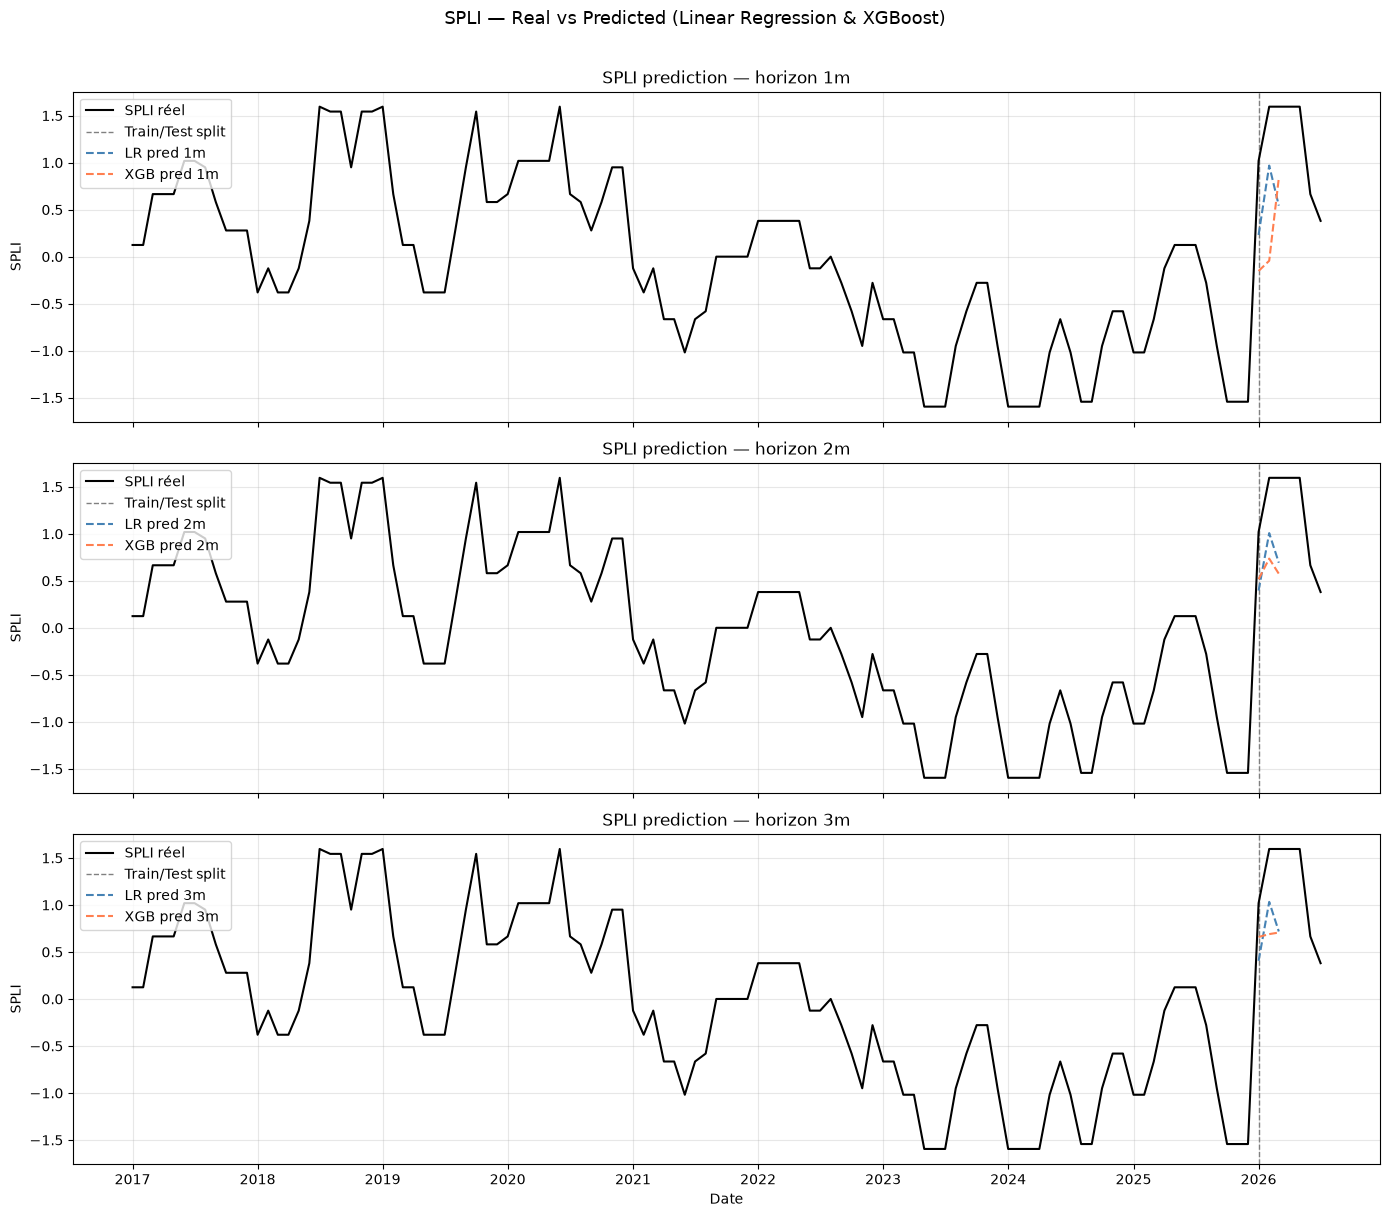

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
horizons = ['1m', '2m', '3m']
df_monthly.index = pd.to_datetime(df_monthly.index.astype(str))
predictions_lr.index = pd.to_datetime(predictions_lr.index.astype(str))
predictions_xgboost_reg.index = pd.to_datetime(predictions_xgboost_reg.index.astype(str))
for i, (ax, horizon) in enumerate(zip(axes, horizons)):
    
    # SPLI réel (toute la série)
    ax.plot(df_monthly.index, df_monthly['SPLI'], 
            color='black', linewidth=1.5, label='SPLI réel', zorder=3)
    
    # Séparation train/test
    ax.axvline(x=predictions_lr.index[0], color='grey', linestyle='--', linewidth=1, label='Train/Test split')
    
    # Prédictions Linear Regression
    ax.plot(predictions_lr.index, predictions_lr[f'y_pred_{horizon}'],
            color='steelblue', linewidth=1.5, linestyle='--', label=f'LR pred {horizon}')
    
    # Prédictions XGBoost
    ax.plot(predictions_xgboost_reg.index, predictions_xgboost_reg[f'y_pred_{horizon}'],
            color='coral', linewidth=1.5, linestyle='--', label=f'XGB pred {horizon}')
    
    ax.set_title(f'SPLI prediction — horizon {horizon}')
    ax.set_ylabel('SPLI')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('SPLI — Real vs Predicted (Linear Regression & XGBoost)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# **TEST DU PREPROCESSING ET DU XGBOOST REGRESSOR EN CHANGEANT LES DATES DU TRAIN/TEST**

In [33]:
def preprocessing(df):
    """
    This function performed the following steps:
    1. preprocessing preparation (dropping undesire columns; splitting the target 'y' and the explicatives features 'X')
    2. Temporal split (X_train; X_test; y_train & y_test)
    At the end, this function return the different datasets to perform Machine Learning algorithms.
    """
    # Setting 'date_index' as index in the dataframe
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    
    # Build the monthly panel
    std_cols = df.filter(regex=r"^S.*I$").columns
    df = df.filter(std_cols)
    df_monthly = df.groupby(df.index.to_period('M')).mean()
    
    # Definition of the target
    df_monthly['SPLI_1m'] = df_monthly['SPLI'].shift(-1) # SPLI from the next month
    df_monthly['SPLI_2m'] = df_monthly['SPLI'].shift(-2) # SPLI from the next two months
    df_monthly['SPLI_3m'] = df_monthly['SPLI'].shift(-3) # SPLI from the next three months
    
    # Temporal split (80/20% for the train/test sets split)
    #df_train = df_monthly.iloc[:-10]
    #df_test = df_monthly.iloc[-10:-7]
    
    df_train = df_monthly.iloc[:-15]
    df_test = df_monthly.iloc[-15:-12]
    
    # Split X/y     
    y_train_1m = df_train['SPLI_1m']
    y_train_2m = df_train['SPLI_2m']
    y_train_3m = df_train['SPLI_3m']
    X_train = df_train.drop(columns=['SPLI', 'SPLI_1m', 'SPLI_2m', 'SPLI_3m'])
   
    y_test_1m = df_test['SPLI_1m']
    y_test_2m = df_test['SPLI_2m']
    y_test_3m = df_test['SPLI_3m']
    X_test = df_test.drop(columns=['SPLI', 'SPLI_1m', 'SPLI_2m', 'SPLI_3m'])
    
    return X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m

In [34]:
X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [36]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    Function to run a XGBoost Regressor on a train and test set.
    Return the prediction and evaluation metrics (R2 on train and test, RMSE, MAE)
    """
    X_train, y_train_1m, y_train_2m, y_train_3m, X_test, y_test_1m, y_test_2m, y_test_3m = preprocessing(df)

    y_trains = [y_train_1m, y_train_2m, y_train_3m]
    y_tests  = [y_test_1m,  y_test_2m,  y_test_3m]

    preds   = {}
    metrics = {'R2_train': [], 'R2_test': [], 'RMSE': [], 'MAE': []}

    for i, (y_train, y_test) in enumerate(zip(y_trains, y_tests), start=1):
        model = XGBRegressor(
            n_estimators     = n_estimators,
            learning_rate    = learning_rate,
            max_depth        = max_depth,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            random_state     = random_state)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        preds[f'y_test_{i}m'] = y_test.values
        preds[f'y_pred_{i}m'] = y_pred

        metrics['R2_train'].append(model.score(X_train, y_train))
        metrics['R2_test'].append(model.score(X_test, y_test))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
        metrics['MAE'].append(mean_absolute_error(y_test, y_pred))

    predictions_xgboost_reg = pd.DataFrame(preds, index=y_test_1m.index)
    evaluation_metrics_xgboost_reg = pd.DataFrame(metrics, index=['Prediction_1m', 'Prediction_2m', 'Prediction_3m'])

    return predictions_xgboost_reg, evaluation_metrics_xgboost_reg

In [37]:
predictions_xgboost_reg, evaluation_metrics_xgboost_reg = xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4, 
                                                                            subsample=0.8, colsample_bytree=0.8, random_state=42)

In [38]:
predictions_xgboost_reg

,y_test_1m,y_pred_1m,y_test_2m,y_pred_2m,y_test_3m,y_pred_3m
date_index,,,,,,
2025-05,0.124164,-0.890828,0.124164,-0.927421,-0.278405,-0.825891
2025-06,0.124164,-0.531999,-0.278405,-0.515771,-0.950014,-0.920140
2025-07,-0.278405,-0.282066,-0.950014,-0.271580,-1.543098,-0.226042


In [39]:
evaluation_metrics_xgboost_reg

,R2_train,R2_test,RMSE,MAE
Prediction_1m,0.996054,-12.520542,0.697799,0.558272
Prediction_2m,0.994527,-1.754611,0.735401,0.655795
Prediction_3m,0.994270,-1.541698,0.823665,0.631472


# **FINAL TEST**

In [37]:
df.columns.tolist()

['latitude',
 'longitude',
 'temperature_2m_max',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'date_index',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur',
 'P_cum_30d',
 'P_cum_90d',
 'Peff_cum_30d',
 'Peff_cum_90d',
 'Temperature_mean_30d',
 'Temperature_mean_90d',
 'SPLI',
 'SPI',
 'SETI',
 'SSTI',
 'SSRI',
 'SWSI',
 'SCCI',
 'SPMI',
 'SPEI',
 'SSMI']

In [74]:
def preprocessing(df):
    """
    Steps:
    1. Set temporal index
    2. Create shifted target: SPLI at t+1 day
    3. Select relevant daily features (numeric, domain-informed)
    4. Temporal train/test split (last 30 days = test set)
    5. Split X / y
    Returns X_train, X_test, y_train, y_test.
    """
    # --- Temporal index ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # --- Shifted target: predict SPLI of next day ---
    df["niveau_nappe_eau_1d"] = df["niveau_nappe_eau"].shift(-1)
    df = df.iloc[:-1]

    # --- Feature selection ---
    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau_1d"

    df = df[feature_cols + [target_col]]  # ✅ garde uniquement ce qui est utile

    # --- Temporal split: last 30 days = test ---
    TEST_SIZE = 30
    df_train = df.iloc[:-TEST_SIZE]
    df_test  = df.iloc[-TEST_SIZE:]

    # --- X / y split ---
    X_train = df_train[feature_cols]
    y_train = df_train[target_col]

    X_test = df_test[feature_cols]
    y_test = df_test[target_col]

    return X_train, X_test, y_train, y_test

In [75]:
X_train, X_test, y_train, y_test = preprocessing(df)

In [76]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [77]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    XGBoost Regressor predicting SPLI at J+1 (next day).
    Returns predictions and evaluation metrics (R2_train, R2_test, RMSE, MAE).
    """
    X_train, X_test, y_train, y_test = preprocessing(df)

    # --- Model ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Predictions ---
    predictions_xgboost_reg = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Metrics ---
    evaluation_metrics_xgboost_reg = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [model.score(X_test, y_test)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)]
    }, index=["niveau_nappe_eau"])

    return predictions_xgboost_reg, evaluation_metrics_xgboost_reg

In [78]:
predictions_xgboost_reg, evaluation_metrics_xgboost_reg = xgboost_regressor(df)

In [79]:
predictions_xgboost_reg

,y_test,y_pred
date_index,,
2026-06-19,104.15,103.746948
2026-06-20,104.16,103.596970
2026-06-21,104.13,103.520607
2026-06-22,104.14,103.611198
2026-06-23,104.15,103.595840
2026-06-24,104.15,103.780914
2026-06-25,104.15,103.671234
2026-06-26,104.12,103.754143
2026-06-27,104.13,103.801643


In [80]:
evaluation_metrics_xgboost_reg

,R2_train,R2_test,RMSE,MAE
niveau_nappe_eau,0.85131,-26.066788,0.595967,0.581655


                  R2_train    R2_test      RMSE       MAE
niveau_nappe_eau   0.85131 -26.066788  0.595967  0.581655


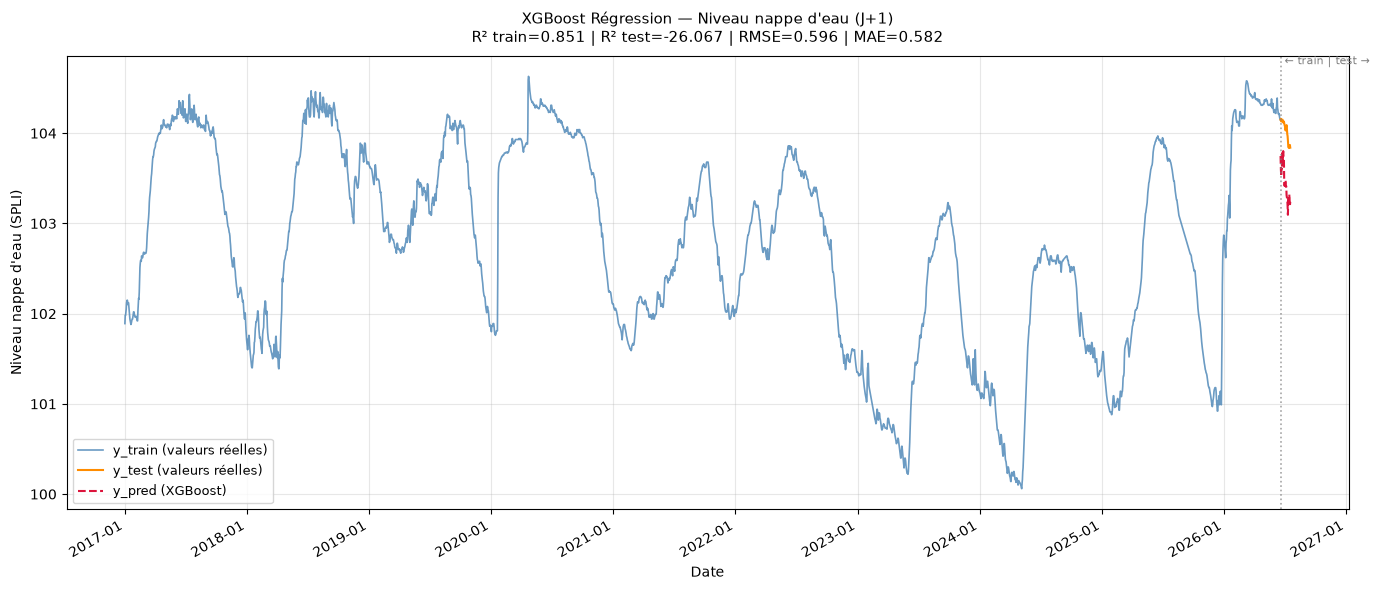

In [81]:
def run_xgboost_pipeline(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                         subsample=0.8, colsample_bytree=0.8, random_state=42,
                         figsize=(14, 6)):
    """
    Pipeline complet : preprocessing → entraînement → métriques → visualisation.
    """
    # --- Preprocessing ---
    X_train, X_test, y_train, y_test = preprocessing(df)

    # --- Modèle ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Prédictions ---
    predictions_df = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Métriques ---
    metrics_df = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [model.score(X_test, y_test)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)]
    }, index=["niveau_nappe_eau"])

    print(metrics_df.to_string())

    # --- Visualisation ---
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(y_train.index, y_train.values,
            color="steelblue", linewidth=1.2, alpha=0.8,
            label="y_train (valeurs réelles)")

    ax.plot(predictions_df.index, predictions_df["y_test"],
            color="darkorange", linewidth=1.5,
            label="y_test (valeurs réelles)")

    ax.plot(predictions_df.index, predictions_df["y_pred"],
            color="crimson", linewidth=1.5, linestyle="--",
            label="y_pred (XGBoost)")

    split_date = predictions_df.index[0]
    ax.axvline(split_date, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
    ax.text(split_date, ax.get_ylim()[1],
            " ← train | test →", fontsize=8, color="gray", va="top")

    row = metrics_df.iloc[0]
    ax.set_title(
        f"XGBoost Régression — Niveau nappe d'eau (J+1)\n"
        f"R² train={row['R2_train']:.3f} | R² test={row['R2_test']:.3f} | "
        f"RMSE={row['RMSE']:.3f} | MAE={row['MAE']:.3f}",
        fontsize=11, pad=10
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Niveau nappe d'eau (SPLI)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate()
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return predictions_df, metrics_df


# ── Exécution ──────────────────────────────────────────────────────────────────
predictions, metrics = run_xgboost_pipeline(df)